In [1]:
import os, re
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D

In [2]:
!mkdir diagrams/tau-study/

In [3]:
tau_results_k5 = {
  "Yelp": {
    "tau":   [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
    "ndcg5": [0.1486, 0.1598, 0.2063, 0.2525, 0.2893, 0.3149, 0.3310, 0.3378, 0.3399, 0.3403],
    "pop5":  [0.1553, 0.1785, 0.2328, 0.2806, 0.3163, 0.3371, 0.3484, 0.3533, 0.3546, 0.3548],
  },
  "Sports": {
    "tau":   [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
    "ndcg5": [0.1134, 0.1379, 0.1482, 0.1505, 0.1514, 0.1516, 0.15161, 0.15162, 0.15163, 0.15164],
    "pop5":  [0.0581, 0.0849, 0.0975, 0.1018, 0.1032, 0.1035, 0.1035, 0.1036, 0.1037, 0.1038],
  },
  "Beauty": {
    "tau":   [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
    "ndcg5": [0.0934, 0.11, 0.1495, 0.1892, 0.2211, 0.2427, 0.254, 0.2594, 0.2604, 0.2604],
    "pop5":  [0.1455, 0.1761, 0.2462, 0.2679, 0.3012, 0.324, 0.3367, 0.3424, 0.3439, 0.3439],
  },
}


In [5]:
DIR_NAME = "diagrams/tau-study/"

In [6]:
# ==========================
# Plot function: one figure per dataset (colored points by τ + legend)
# ==========================
def plot_tradeoff_by_dataset_k5(name, vals, outdir="."):
    taus  = np.array(vals["tau"], dtype=float)
    ndcg5 = np.array(vals["ndcg5"], dtype=float)
    pop5  = np.array(vals["pop5"], dtype=float)

    if len(taus) == 0:
        print(f"{name}: no K=5 data; skipping.")
        return

    # Order by tau
    order = np.argsort(taus)
    taus, ndcg5, pop5 = taus[order], ndcg5[order], [1 - x for x in pop5[order]]

    # Color map for τ values
    cmap = cm.get_cmap('plasma', len(taus))
    norm = mcolors.Normalize(vmin=min(taus), vmax=max(taus))
    colors = [cmap(norm(t)) for t in taus]

    fig, ax = plt.subplots(figsize=(7,5), constrained_layout=True)

    # Plot line + colored points
    ax.plot(pop5, ndcg5, color="gray", linewidth=1.2, alpha=0.5, zorder=1)
    for x, y, c in zip(pop5, ndcg5, colors):
        ax.scatter(x, y, color=c, s=200, edgecolor="black", 
                   linewidth=0.4, zorder=2,alpha=0.7)

    # Highlight best-NDCG point
#     best_idx = int(np.argmax(ndcg5))
#     ax.scatter(pop5[best_idx], ndcg5[best_idx],
#                marker='s', s=200, color=colors[best_idx],
#                edgecolor='black', linewidth=0.6, zorder=3)

    # Labels/title
    ax.set_xlabel("LongTailRate@5 (higher is better)",fontsize=15)
    ax.set_ylabel("NDCG@5 (higher is better)",fontsize=15)
    ax.set_title(f"{name}: NDCG@5 vs LongTailRate@5 across τ",fontsize=18)

    # Tighter axes
    x_min, x_max = np.min(pop5), np.max(pop5)
    y_min, y_max = np.min(ndcg5), np.max(ndcg5)
    ax.set_xlim(x_min - 0.01, x_max + 0.01)
    ax.set_ylim(y_min - 0.01, y_max + 0.01)

    # Legend showing τ values
    legend_handles = [
        Line2D([0],[0], marker='o', color='w', label=f"τ={t:.1f}",
               markerfacecolor=cmap(norm(t)), markeredgecolor='black', markersize=15)
        for t in taus
    ]
    ax.legend(handles=legend_handles, title="τ values",
              fontsize=13, title_fontsize=12, ncol=2, loc="upper right")

    # Styling
    ax.grid(linestyle="--", alpha=0.3)
    for spine in ("top","right"): ax.spines[spine].set_visible(False)
    ax.tick_params(axis='both', labelsize=15)

    fig.tight_layout()
    plt.show()

    # # Uncomment to save:
    if outdir:
        out = os.path.join(outdir, f"tau_tradeoff_k5_{re.sub(r'[^A-Za-z0-9_-]+','_',name)}.png")
        fig.savefig(out, dpi=200, bbox_inches="tight")
    
    plt.close(fig)
    return 


<ipython-input-6-e741450d0279>:61: UserWarning: This figure was using constrained_layout==True, but that is incompatible with subplots_adjust and or tight_layout: setting constrained_layout==False. 
  fig.tight_layout()


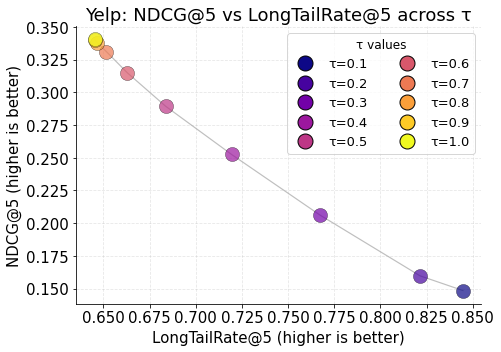

In [7]:
# ==========================
# Generate all figures
# ==========================
saved_paths = plot_tradeoff_by_dataset_k5("Yelp",tau_results_k5["Yelp"], 
                                          outdir=f"{DIR_NAME}/")


<ipython-input-6-e741450d0279>:61: UserWarning: This figure was using constrained_layout==True, but that is incompatible with subplots_adjust and or tight_layout: setting constrained_layout==False. 
  fig.tight_layout()


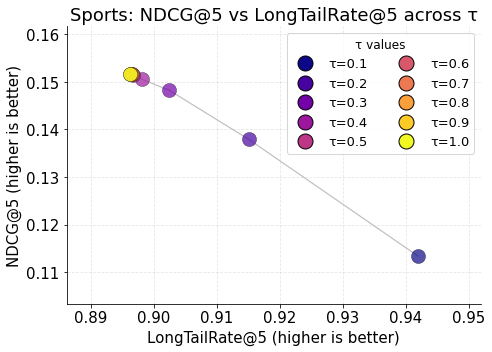

In [8]:
saved_paths = plot_tradeoff_by_dataset_k5("Sports",tau_results_k5["Sports"]
                                          ,outdir=f"{DIR_NAME}/")


<ipython-input-6-e741450d0279>:61: UserWarning: This figure was using constrained_layout==True, but that is incompatible with subplots_adjust and or tight_layout: setting constrained_layout==False. 
  fig.tight_layout()


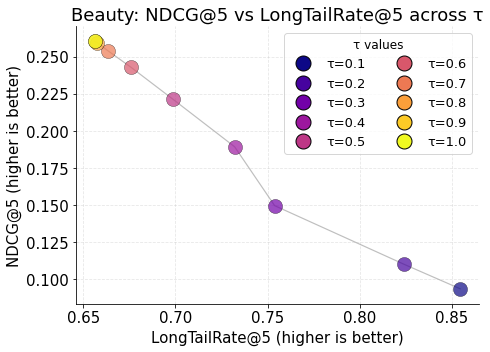

In [9]:
saved_paths = plot_tradeoff_by_dataset_k5("Beauty",tau_results_k5["Beauty"], 
                                          outdir=f"{DIR_NAME}/")
